# Meausure energy-energy correlators with Omnifold measurement

This notebook implements a measurement of the two-point energy correlator observable (EEC) using the ATLAS Omnifold Z+jets measurement. The observable is first examined using the "pseudo-measurement" and statistical agreement with the target truth pseudodata distribution is checked. Then the results of the measurement on data are presented.

Note given that re-calculating the energy products and angular coordinates of track pairs is relatively inexpensive once parallelized, this notebook does not pre-compute these results and write them to disk. Instead the histogramming is the compute expensive step. For better performance, both steps are parallelized using dask delayed. See `eec_utils.py` for details.

## Preliminaries: load all data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import pickle
import numpy as np
import pandas as pd
import dask.distributed as distributed

import eec_utils as eec
import visualize as vis

In [3]:
# ROOT file paths
staging_dir = "/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data"
tree_name = "OmniTree"

truth_mc_path = f"{staging_dir}/truth_mc_events.root"
truth_pseudodata_path = f"{staging_dir}/truth_pseudodata_events.root"
truth_hv_path = f"{staging_dir}/truth_mc_hv_events.root"
truth_madgraph_path = f"{staging_dir}/truth_madgraph/truth_madgraph_events.root"
truth_sherpa_path = f"{staging_dir}/truth_sherpa/truth_sherpa_events_part1.root"

In [4]:
# Load event weights for pseudodata measurement
pseudodata_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/pseudodata_weights.h5")
pseudodata_hv_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/pseudodata_hv_weights.h5")
truth_pseudodata_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/truth_pseudodata_weights.h5")

# Load event weights for data measurement
data_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/data_weights.h5")
data_hv_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/data_hv_weights.h5")
truth_madgraph_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/truth_madgraph/truth_madgraph_weights.h5")
truth_sherpa_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/truth_sherpa/truth_sherpa_weights_part1.h5")

## Measurement with Pseudodata

In [ ]:
# Create dictionary containined all of the weight vectors needed for the pseudodata measurement
nominal_weights = pseudodata_weights["weights_nominal"].to_numpy()
n_init_weights = [name for name in pseudodata_weights.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in pseudodata_weights.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_train_weights = [name for name in pseudodata_weights.keys() if "weights_bootstrap_mc_" in name]
pd_weights = {
    "prior": pseudodata_weights["weights_prior"].to_numpy(),  # Also include weights for plotting the "prior" used in the measurement
    "nominal": nominal_weights,
    **{f"ensemble_{i}": pseudodata_weights[name].to_numpy() for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": pseudodata_weights[name].to_numpy() for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": pseudodata_weights[name].to_numpy() for i, name in enumerate(mcbootstrap_train_weights)},
    "trackEffMain": pseudodata_weights["weights_trackEffMain"].to_numpy(),
    "trackEffJet": pseudodata_weights["weights_trackEffJet"].to_numpy(),
    "trackFake": pseudodata_weights["weights_trackFake"].to_numpy(),
    "trackPtScale": pseudodata_weights["weights_trackPtScale"].to_numpy(),
    # "muCalID": pseudodata_weights["weights_muCalID"].to_numpy(),
    # "muCalMS": pseudodata_weights["weights_muCalMS"].to_numpy(),
    # "muCalResBias": pseudodata_weights["weights_muCalResBias"].to_numpy(),
    # "muCalScale": pseudodata_weights["weights_muCalScale"].to_numpy(),
    "muEffReco": pseudodata_weights["weights_muEffReco"].to_numpy(),
    "muEffIso": pseudodata_weights["weights_muEffIso"].to_numpy(),
    "muEffTrack": pseudodata_weights["weights_muEffTrack"].to_numpy(),
    "muEffTrig": pseudodata_weights["weights_muEffTrig"].to_numpy(),
    "pileup": pseudodata_weights["weights_pileup"].to_numpy(),
    "lumi": pseudodata_weights["weights_lumi"].to_numpy(),
    "dd": pseudodata_weights["weights_dd"].to_numpy(),
    "target_dd": pseudodata_weights["target_dd"].to_numpy(),
    "hvhad": pseudodata_weights["weights_hvhad"].to_numpy(),
}
truth_pd_weights = {
    "truthpd": truth_pseudodata_weights["weights_nominal"].to_numpy(),
}
pd_hv_weights = {
    "hv": pseudodata_hv_weights["weights_hv"].to_numpy(),
}

In [ ]:
bins = np.logspace(-6, -1, 20)
# bins = np.linspace(0, 1, 30)

In [ ]:
# Run computations with dask
cluster = distributed.LocalCluster(
    n_workers=100,
    threads_per_worker=2,
    memory_limit="auto",
)
client = distributed.Client(cluster)

print("Histogramming Madgraph MC sample")
truth_mc_hists = eec.run_eec_workflow_parallel(
    truth_mc_path,
    "OmniTree",
    pd_weights,
    bins,
    chunk_size=1000,
)
print("Histogramming HV sample")
truth_hv_hists = eec.run_eec_workflow_parallel(
    truth_hv_path,
    "OmniTree",
    pd_hv_weights,
    bins,
    chunk_size=1000,
)
print("Histogramming Truth Pseudodata sample")
truth_pd_hists = eec.run_eec_workflow_parallel(
    truth_pseudodata_path,
    "OmniTree",
    truth_pd_weights,
    bins,
    chunk_size=1000,
)

client.close()
cluster.close()

In [ ]:
# Pickle the resulting histograms
hist_dir = "./hist_storage"
if not os.path.exists(hist_dir):
    os.makedirs(hist_dir)

with open(os.path.join(hist_dir, "pd_eec_hists.pkl"), "wb") as f:
    pickle.dump(
        {
            "truth_mc": truth_mc_hists,
            "truth_hv": truth_hv_hists,
            "truth_pd": truth_pd_hists,
        },
        f,
    )

### Plotting

In [3]:
# Load the histograms
hist_dir = "./hist_storage"
with open(os.path.join(hist_dir, "pd_eec_hists.pkl"), "rb") as f:
    all_hists = pickle.load(f)

measurement_hists = {**all_hists["truth_mc"], **all_hists["truth_hv"]}
truth_pd_hists = all_hists["truth_pd"]

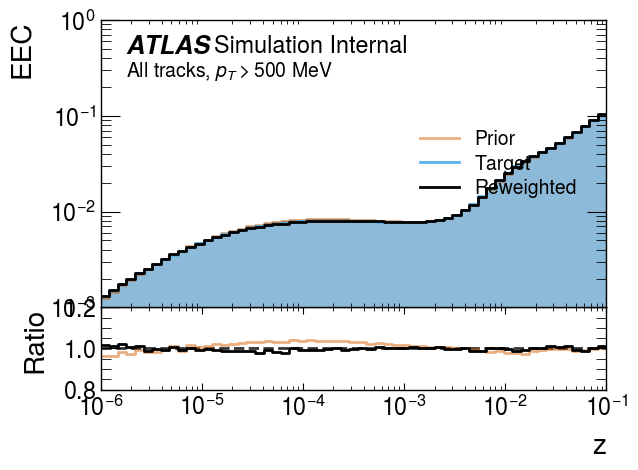

In [4]:
# Plot comparison to truth pseudodata (no uncertainties)
import visualize as vis
comp = vis.compare_to_target(
    measurement_hists,
    truth_pd_hists,
    log_xscale=True,
    linear_yscale=False,
    ylabel="EEC",
    xlabel="z",
    normalize=True,
    rlab="All tracks, $p_T > 500$ MeV",
)
comp.savefig("plot_storage/pd_eec_reweighting.pdf", dpi=300)
comp.show()

Chi-squared test: dof=59, χ²=66.38482, p-value=0.2376


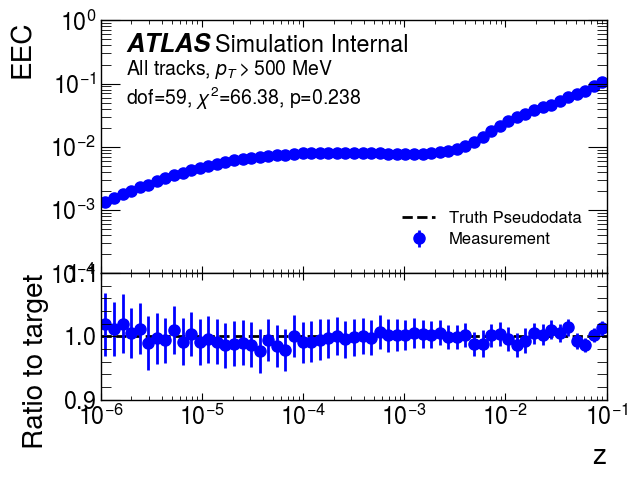

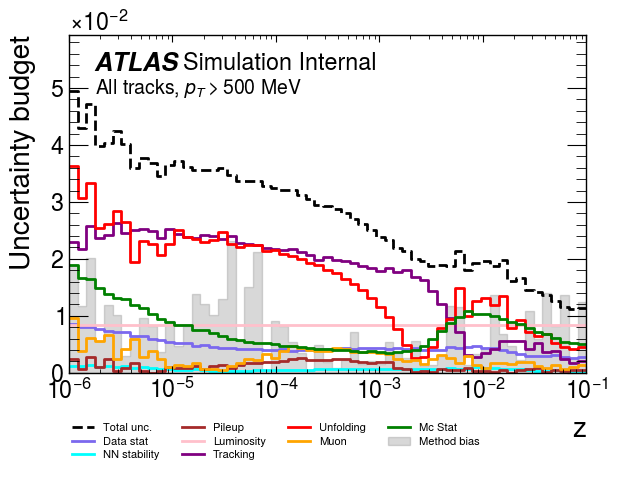

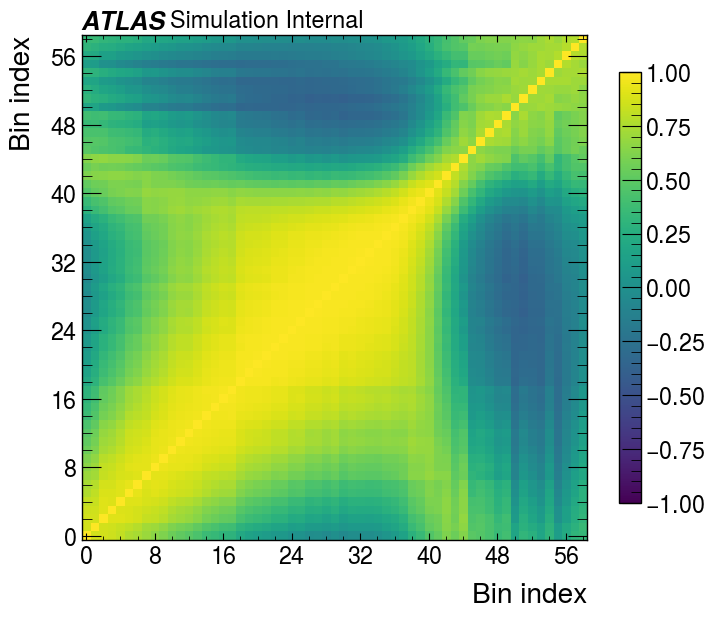

In [6]:
# Plot pseudo-measurement and uncertainty budget
import visualize as vis

xsec, budget, cov = vis.plot_measurement_with_uncertainties(
    measurement_hists,
    truth_pd_hists,
    figsize=(6.4, 4.8),
    color="blue",
    log_xscale=True,
    linear_yscale=False,
    ylabel="EEC",
    xlabel="z",
    normalize=True,
    rlab="All tracks, $p_T > 500$ MeV",
    simple_corr_labels=True,
    do_chi2_test=True,
    ylim=(1e-4, 1e0),
)
xsec.savefig("plot_storage/pd_eec_xsec.pdf", dpi=300)
xsec.show()
budget.savefig("plot_storage/pd_eec_budget.pdf", dpi=300)
budget.show()
cov.savefig("plot_storage/pd_eec_cov.pdf", dpi=300)
cov.show()

## Measurement with data

In [10]:
# Create dictionary describing all of the histograms needed for the data measurement
nominal_weights = data_weights["weights_nominal"]
n_init_weights = [name for name in data_weights.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in data_weights.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_train_weights = [
    name for name in data_weights.keys() if "weights_bootstrap_mc_" in name
]
data_weights = {
    "nominal": data_weights["weights_nominal"].to_numpy(),
    **{f"ensemble_{i}": data_weights[name].to_numpy() for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": data_weights[name].to_numpy() for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": data_weights[name].to_numpy() for i, name in enumerate(mcbootstrap_train_weights)},
    "trackEffMain": data_weights["weights_trackEffMain"].to_numpy(),
    "trackEffJet": data_weights["weights_trackEffJet"].to_numpy(),
    "trackFake": data_weights["weights_trackFake"].to_numpy(),
    "trackPtScale": data_weights["weights_trackPtScale"].to_numpy(),
    # "muCalID": data_weights["weights_muCalID"].to_numpy(),
    # "muCalMS": data_weights["weights_muCalMS"].to_numpy(),
    # "muCalResBias": data_weights["weights_muCalResBias"].to_numpy(),
    # "muCalScale": data_weights["weights_muCalScale"].to_numpy(),
    "muEffReco": data_weights["weights_muEffReco"].to_numpy(),
    "muEffIso": data_weights["weights_muEffIso"].to_numpy(),
    "muEffTrack": data_weights["weights_muEffTrack"].to_numpy(),
    "muEffTrig": data_weights["weights_muEffTrig"].to_numpy(),
    "pileup": data_weights["weights_pileup"].to_numpy(),
    "lumi": data_weights["weights_lumi"].to_numpy(),
    "dd": data_weights["weights_dd"].to_numpy(),
    "target_dd": data_weights["target_dd"].to_numpy(),
    "hvhad": data_weights["weights_hvhad"].to_numpy(),
}
data_hv_weights = {
    "hv": data_hv_weights["weights_hv"].to_numpy(),
}
truth_madgraph_weights_dict = {
    "madgraph": truth_madgraph_weights["weights_nominal"],
    "theoryQCD": truth_madgraph_weights["weights_theoryQCD"],
    "theoryPDF": truth_madgraph_weights["weights_theoryPDF"],
    "theoryAlphaS": truth_madgraph_weights["weights_theoryAlphaS"],
    "theoryPSsoft": truth_madgraph_weights["weights_theoryPSsoft"],
    "theoryPSjet": truth_madgraph_weights["weights_theoryPSjet"],
    "theoryPSscale": truth_madgraph_weights["weights_theoryPSscale"],
    "theoryMPI": truth_madgraph_weights["weights_theoryMPI"],
}
truth_sherpa_weights_dict = {
    "sherpa": truth_sherpa_weights["weights_nominal"],
    "theoryQCD": truth_sherpa_weights["weights_theoryQCD"],
    "theoryPDF": truth_sherpa_weights["weights_theoryPDF"],
    "theoryAlphaS": truth_sherpa_weights["weights_theoryAlphaS"],
}

In [16]:
bins = np.logspace(-4.3, -1, 20)
# bins = np.linspace(0, 1, 30)

In [17]:
# Run computations with dask
n_cores = os.cpu_count()
cluster = distributed.LocalCluster(
    n_workers=100,
    threads_per_worker=2,
    memory_limit="auto",
)
client = distributed.Client(cluster)

print("Histogramming Madgraph MC sample")
truth_mc_hists = eec.run_eec_workflow_parallel(
    truth_mc_path,
    "OmniTree",
    data_weights,
    bins,
    chunk_size=1000,
    invert_z=True,
)
print("Histogramming HV sample")
truth_hv_hists = eec.run_eec_workflow_parallel(
    truth_hv_path,
    "OmniTree",
    data_hv_weights,
    bins,
    chunk_size=1000,
    invert_z=True,
)
print("Histogramming Madgraph prediction")
truth_madgraph_hists = eec.run_eec_workflow_parallel(
    truth_madgraph_path,
    "OmniTree",
    truth_madgraph_weights,
    bins,
    chunk_size=1000,
    invert_z=True,
)
print("Histogramming Sherpa prediction")
truth_sherpa_hists = eec.run_eec_workflow_parallel(
    truth_sherpa_path,
    "OmniTree",
    truth_sherpa_weights,
    bins,
    chunk_size=1000,
    max_events=5000000,
    invert_z=True,
)

client.close()
cluster.close()

Histogramming Madgraph MC sample


/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 1.18 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Histogramming HV sample


/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 10.95 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Histogramming Madgraph prediction


/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 432.50 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Histogramming Sherpa prediction


/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 467.63 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2026-03-17 08:01:26,847 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.78 GiB -- Worker memory limit: 3.93 GiB
2026-03-17 08:02:17,542 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/global/common/software/m3246/conda/eflow/lib/python3.11/

In [18]:
# Pickle the resulting histograms
hist_dir = "./hist_storage"
with open(os.path.join(hist_dir, "data_eec_b2b_hists.pkl"), "wb") as f:
    pickle.dump(
        {
            "truth_mc": truth_mc_hists,
            "truth_hv": truth_hv_hists,
            "truth_madgraph": truth_madgraph_hists,
            "truth_sherpa": truth_sherpa_hists,
        },
        f,
    )

## Plotting

In [19]:
# Load the histograms
hist_dir = "./hist_storage"
with open(os.path.join(hist_dir, "data_eec_b2b_hists.pkl"), "rb") as f:
    all_hists = pickle.load(f)

measurement_hists = {**all_hists["truth_mc"], **all_hists["truth_hv"]}
truth_madgraph_hists = all_hists["truth_madgraph"]
truth_sherpa_hists = all_hists["truth_sherpa"]

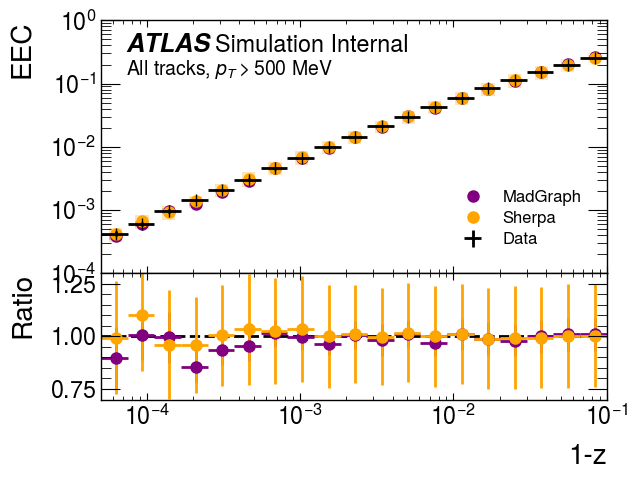

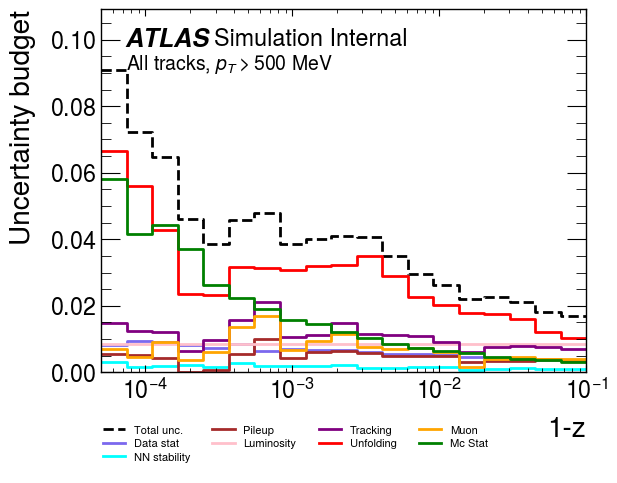

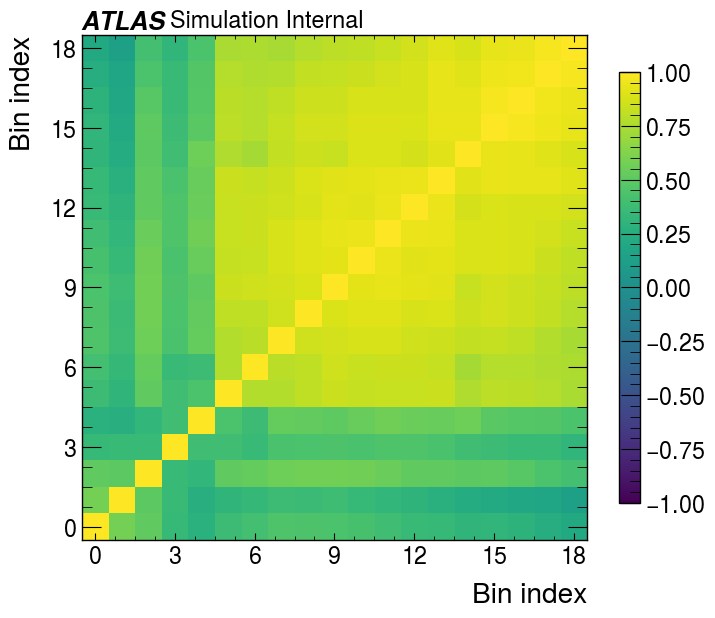

In [21]:
# Plot data measurement and uncertainty budget
xsec, budget, cov = vis.plot_measurement_with_uncertainties(
    measurement_hists,
    truth_madgraph_hists,
    truth_sherpa_hists,
    measured_label="Data",
    target_key="weights_nominal",
    target_label="MadGraph",
    target2_key="weights_nominal",
    target2_label="Sherpa",
    data_measurement_mode=True,
    color="black",
    linear_yscale=False,
    log_xscale=True,
    ylabel="EEC",
    xlabel="1-z",
    normalize=True,
    rlab="All tracks, $p_T > 500$ MeV",
    ylim=(1e-4, 1e0),
    rlim=(0.7, 1.3),
    simple_corr_labels=True,
)
xsec.savefig("plot_storage/data_eec_b2b.pdf", dpi=300)
xsec.show()
budget.savefig("plot_storage/data_eec_b2b_budget.pdf", dpi=300)
budget.show()
cov.savefig("plot_storage/data_eec_b2b_cov.pdf", dpi=300)
cov.show()